#Exercise
This is a dataset related to how much money a person can get from a mortgage on his or her home. This dataset includes the following features:
* Gender: Gender of the borrower (including two values 'F' and 'M')
* Age: Age of the customer applying for a loan (including positive integer values)
* Income (USD): Customer's income in USD (value is a positive number)
* Income Stability: The level of customer's income stability (including three values of Low and High)
* Property Age: Life expectancy of the house in days (including positive integer values)
* Property Location: Location of the house (including 'Rural', 'Urban', and 'Semi-Urban')
* Property Price: The value of the house in USD (including positive real values)
* Loan Sanction Amount (USD): Amount that customers can borrow in USD (target value)

Based on practice sample #1, proceed:
1. Read data
2. Visualize some information of data
3. Normalize Data to train linear regression model
4. Train linear regression model and show the model's intercepts, coeficients
5. Learn on sklearn how to use Ridge, Lasso, and ElasticNet compare the error of all 3 algorithms with Linear Regression (https://scikit-learn.org/stable/index.html)
6. Let's try Polynomial of order 2 to compare the previous results. What will the result be if we choose the n order too high?

In [1]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time


# Prepare and Analyze Data

1. Load Dataset
2. Analyze Dataset
3. Preprocess data (type, null, missing, ...)
4. Feature Engineering

## Load Dataset

In [4]:
def read_dataset(path):
    df = pd.read_csv(path)
    display(df.head())
    display(df.describe())
    return df

In [5]:
PATH = "final_house_loan.csv"

df = read_dataset(PATH)

,Gender,Age,Income (USD),Income Stability,Property Age,Property Location,Property Price,Loan Sanction Amount (USD)
0,F,19,1641.25,Low,1651.25,Rural,59641.82,21026.420753
1,M,29,1989.71,Low,1990.71,Urban,179858.51,60595.183366
2,F,37,1849.91,Low,1856.91,Rural,117297.62,39181.648002
3,M,65,2735.18,High,2747.18,Rural,354417.72,128497.710865
4,F,62,4741.78,High,4740.78,Urban,82049.80,39386.919336


,Age,Income (USD),Property Age,Property Price,Loan Sanction Amount (USD)
count,47297.000000,47265.000000,47263.000000,4.729700e+04,47297.000000
mean,40.000063,2586.684384,2586.611058,1.350880e+05,46487.229765
std,16.086128,1558.768809,1558.842286,9.457875e+04,32549.905634
min,18.000000,372.700000,370.700000,7.859620e+03,254.586578
25%,24.000000,1653.740000,1652.820000,6.250408e+04,21782.822159
50%,40.000000,2245.480000,2244.810000,1.130936e+05,38822.132402
75%,55.000000,3128.560000,3128.380000,1.819546e+05,62612.236905
max,65.000000,54662.750000,54647.750000,1.077967e+06,366131.165218


In [6]:
print("Number of rows : {}".format(df.shape[0]))
print("Number of columns : {}".format(df.shape[1]))

Number of rows : 47297
Number of columns : 8


## Data Analysis

<Axes: >

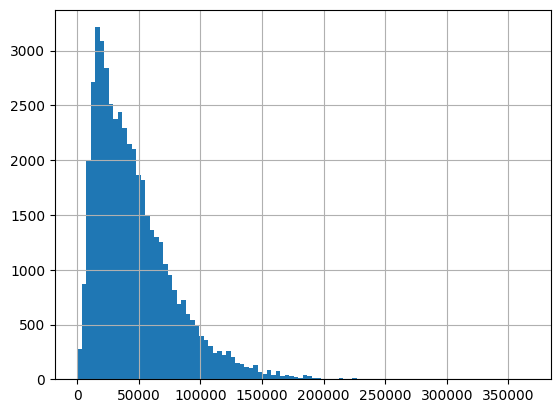

In [7]:
df["Loan Sanction Amount (USD)"].hist(bins=100)

<Axes: xlabel='Loan Sanction Amount (USD)', ylabel='Count'>

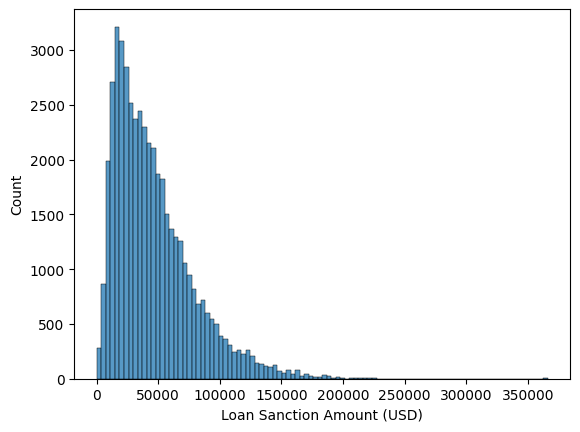

In [8]:
sns.histplot(x="Loan Sanction Amount (USD)", data=df, bins=100)

In [12]:
print("Continous Columns")
continous_columns = df.describe().columns
print(continous_columns)

print("Categorical Columns")
categorical_columns = df.describe(include=[object]).columns
print(categorical_columns)

Continous Columns
Index(['Age', 'Income (USD)', 'Property Age', 'Property Price',
       'Loan Sanction Amount (USD)'],
      dtype='object')
Categorical Columns
Index(['Gender', 'Income Stability', 'Property Location'], dtype='object')


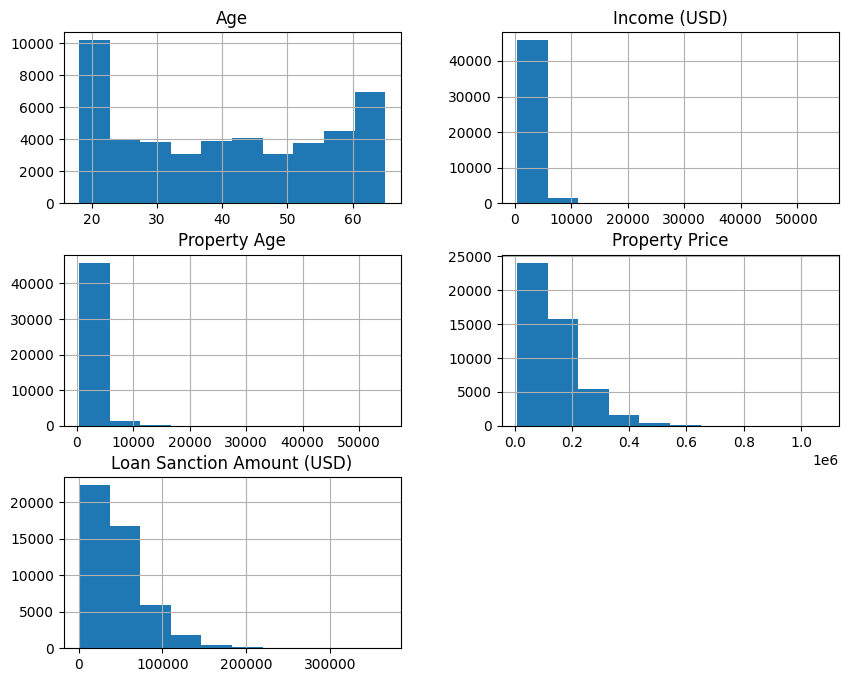

In [17]:
df.hist(column=continous_columns, figsize=(10,8))
plt.show()

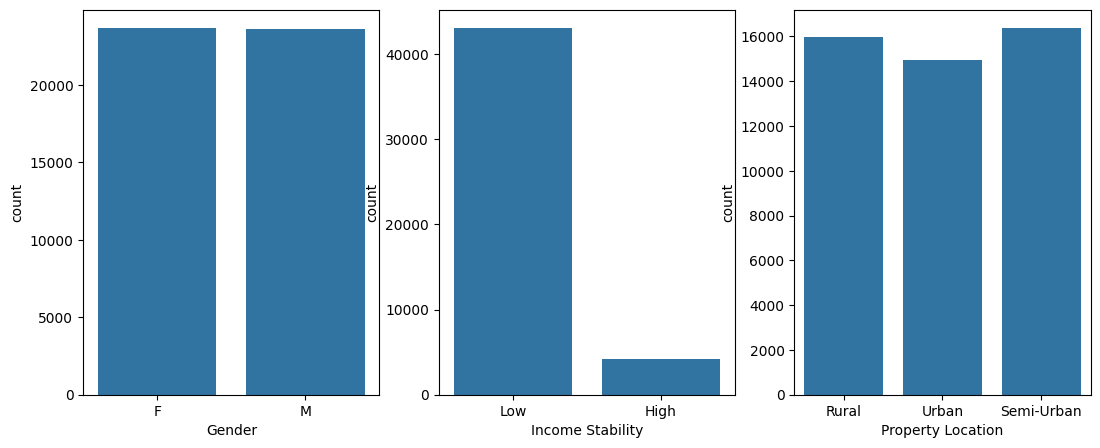

In [38]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(13, 5))

for i, col in enumerate(categorical_columns):
    sns.countplot(data=df, x=col, ax=axes[i])
    
plt.show()

In [39]:
df.isnull().sum()

Gender                         0
Age                            0
Income (USD)                  32
Income Stability              12
Property Age                  34
Property Location              3
Property Price                 0
Loan Sanction Amount (USD)     0
dtype: int64

## Preprocessing

In [40]:
def preprocessing_data(df):
    df = df.dropna()
    return df

In [41]:
df_ = preprocessing_data(df.copy())

In [42]:
df_.isnull().sum()

Gender                        0
Age                           0
Income (USD)                  0
Income Stability              0
Property Age                  0
Property Location             0
Property Price                0
Loan Sanction Amount (USD)    0
dtype: int64

## Feature Engineering

In [43]:
def normalize_data(df):
    start_time = time.time()
    
    for i, col in enumerate(categorical_columns):
        df[col] = df[col].astype("category").cat.codes
    # df["Gender"] = df["Gender"].astype("category").cat.codes
    # df["Income Stability"] = df["Income Stability"].astype("category").cat.codes
    # df["Property Location"] = df["Property Location"].astype("category").cat.codes
    
    display(df.head())
    display(df.corr())
    print("Running time", time.time() - start_time)
    return df
    

,Gender,Age,Income (USD),Income Stability,Property Age,Property Location,Property Price,Loan Sanction Amount (USD)
0,0,19,1641.25,1,1651.25,0,59641.82,21026.420753
1,1,29,1989.71,1,1990.71,2,179858.51,60595.183366
2,0,37,1849.91,1,1856.91,0,117297.62,39181.648002
3,1,65,2735.18,0,2747.18,0,354417.72,128497.710865
4,0,62,4741.78,0,4740.78,2,82049.80,39386.919336


,Gender,Age,Income (USD),Income Stability,Property Age,Property Location,Property Price,Loan Sanction Amount (USD)
Gender,1.000000,0.007706,-0.002445,-0.019000,-0.002512,0.009142,0.005931,0.003396
Age,0.007706,1.000000,-0.044086,-0.455855,-0.044085,-0.007770,-0.003274,-0.000115
Income (USD),-0.002445,-0.044086,1.000000,0.080961,0.999986,-0.000199,0.358110,0.392897
Income Stability,-0.019000,-0.455855,0.080961,1.000000,0.081008,-0.001959,0.004813,-0.070969
Property Age,-0.002512,-0.044085,0.999986,0.081008,1.000000,-0.000233,0.358110,0.392892
Property Location,0.009142,-0.007770,-0.000199,-0.001959,-0.000233,1.000000,-0.000898,-0.001988
Property Price,0.005931,-0.003274,0.358110,0.004813,0.358110,-0.000898,1.000000,0.994429
Loan Sanction Amount (USD),0.003396,-0.000115,0.392897,-0.070969,0.392892,-0.001988,0.994429,1.000000


Running time 0.0318911075592041


<Axes: >

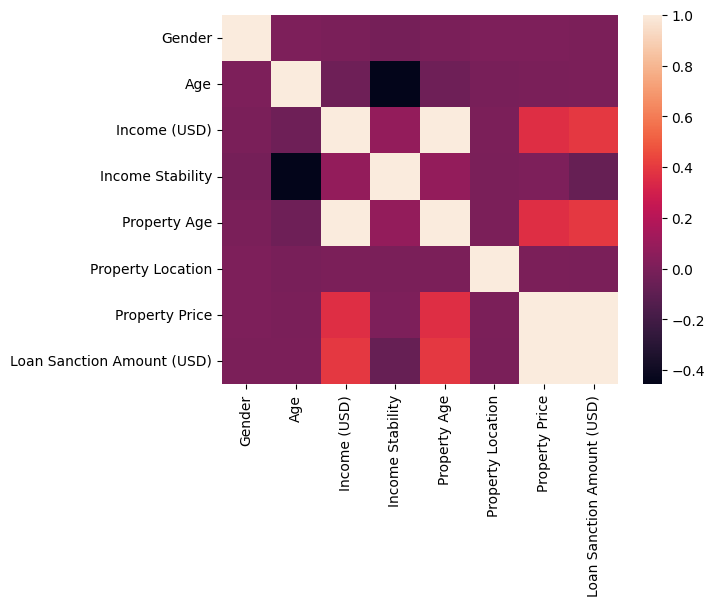

In [44]:
df_ = normalize_data(df_)
sns.heatmap(df_.corr())

# Apply machine learning model

## Train-test split

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [46]:
def prepare_X_y(df):
    columns = df.columns.tolist()
    columns.remove('Loan Sanction Amount (USD)')
    
    X = df[columns]
    y = df['Loan Sanction Amount (USD)']
    return X, y

X, y = prepare_X_y(df_)

In [47]:
def split_train_test(X, y, train_size=0.7):
    trainX, testX ,trainY, testY = train_test_split(X, y, train_size=train_size, random_state=2023)
    print('Training:' + str(trainX.shape))
    print('Test:' + str(testX.shape))

    return trainX, testX ,trainY, testY

In [48]:
TRAIN_SIZE = 0.7

trainX, testX ,trainY, testY = split_train_test(X, y, train_size=TRAIN_SIZE)

Training:(33075, 7)
Test:(14176, 7)


## Basic Linear Regression

### Linear 

In [49]:
from sklearn.linear_model import LinearRegression


def build_linear_model(X, y):
    model = LinearRegression(fit_intercept=True)
    model.fit(trainX, trainY)

    return model

model = build_linear_model(trainX, trainY)
# Compare on training dataset
pred = model.predict(trainX)
print("mean absolute error of linear model on train set ", mean_absolute_error(y_pred=pred, y_true=trainY) )

pred = model.predict(testX)
print("mean absolute error of linear model on test set ", mean_absolute_error(y_pred=pred, y_true=testY) )


mean absolute error of linear model on train set  163.14116153147404
mean absolute error of linear model on test set  137.10457506738928


In [50]:
print(model.coef_) # print coefficient
print()
print(model.intercept_) # print intercept_

[-2.34483815e+02 -7.93861753e+01  5.50183711e-01 -1.11431363e+04
  4.74551612e-01 -6.02929137e+01  3.36339576e-01]

11896.351699425097


### Lasso

In [51]:
from sklearn.linear_model import Lasso
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning

simplefilter("ignore", category=ConvergenceWarning)

def build_lasso_model(X, y):
    model = Lasso(fit_intercept=True)
    model.fit(trainX, trainY)

    return model

model = build_lasso_model(trainX, trainY)
# Compare on training dataset
pred = model.predict(trainX)
print("mean absolute error of linear model on train set ", mean_absolute_error(y_pred=pred, y_true=trainY) )
pred = model.predict(testX)
print("mean absolute error of linear model on test set ", mean_absolute_error(y_pred=pred, y_true=testY) )

mean absolute error of linear model on train set  163.8274651183116
mean absolute error of linear model on test set  137.76715598358135


In [52]:
print(model.coef_) # print coefficient
print()
print(model.intercept_) # print intercept_

[-2.30411413e+02 -7.92539710e+01  8.56088453e-01 -1.11270030e+04
  1.68487165e-01 -5.87931826e+01  3.36340395e-01]

11873.145648014164


### Ridge

In [53]:
from sklearn.linear_model import Ridge


def build_ridge_model(X, y):
    model = Ridge(fit_intercept=True)
    model.fit(trainX, trainY)

    return model

model = build_ridge_model(trainX, trainY)
# Compare on training dataset
pred = model.predict(trainX)
print("mean absolute error of linear model on train set ", mean_absolute_error(y_pred=pred, y_true=trainY) )
pred = model.predict(testX)
print("mean absolute error of linear model on test set ", mean_absolute_error(y_pred=pred, y_true=testY) )


mean absolute error of linear model on train set  163.2710490298598
mean absolute error of linear model on test set  137.2228629130478


In [54]:
print(model.coef_) # print coefficient
print()
print(model.intercept_) # print intercept_

[-2.34413176e+02 -7.93438667e+01  5.51497568e-01 -1.11378235e+04
  4.73173643e-01 -6.02824252e+01  3.36339895e-01]

11889.89289503533


### Elastic

In [55]:
from sklearn.linear_model import ElasticNet


def build_elastic_model(X, y):
    model = ElasticNet(fit_intercept=True)
    model.fit(trainX, trainY)

    return model

model = build_elastic_model(trainX, trainY)
# Compare on training dataset
pred = model.predict(trainX)
print("mean absolute error of linear model on train set ", mean_absolute_error(y_pred=pred, y_true=trainY) )
pred = model.predict(testX)
print("mean absolute error of linear model on test set ", mean_absolute_error(y_pred=pred, y_true=testY) )


mean absolute error of linear model on train set  1747.9078370296193
mean absolute error of linear model on test set  1741.86546613451


In [56]:
print(model.coef_) # print coefficient
print()
print(model.intercept_) # print intercept_

[-5.12544859e+01 -6.45818816e-01  9.42776511e-01 -1.25268452e+03
 -3.74934647e-02 -2.56549075e+01  3.36931714e-01]

-166.83186339290114


## Polynomial Transform

When the data feature does not conform to a linear function, a linear regression cannot be applied directly to the original data. Then, there are many possibilities that the data feature conforms to the polynomial function. Scikit-Learn supports converting data features to polynomials through ``PolynomialFeatures``.

$$
y = a_0 + a_1 x + a_2 x^2 + a_3 x^3 + \cdots
$$

The formula above uses the transformation of the value $x$ from one dimension to the other, with the aim of being able to use linear regression to find complex relationships between $x$ and $y$.

In [57]:
#Linear Regression with Polynomial Transform
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

def build_pipeline(X, y):
    poly_model = make_pipeline(PolynomialFeatures(2, include_bias=False), LinearRegression())
    poly_model.fit(X, y)

    return poly_model
poly_model = build_pipeline(trainX, trainY)

# Compare on training dataset
poly_pred = poly_model.predict(trainX)
print("mean absolute error of linear model (with poly transform) on train set ", mean_absolute_error(y_pred=poly_pred, y_true=trainY) )

poly_pred = poly_model.predict(testX)
print("mean absolute error of linear model (with poly transform) on test set ", mean_absolute_error(y_pred=poly_pred, y_true=testY))

mean absolute error of linear model (with poly transform) on train set  202.84981748055577
mean absolute error of linear model (with poly transform) on test set  176.80844674775108
